In [ ]:
from typing import TypedDict, Annotated
from langchain_core.messages import BaseMessage
import operator

class AgentState(TypedDict):
    messages: Annotated[list[BaseMessage], operator.add]

In [ ]:
from langchain_huggingface import ChatHuggingFace, HuggingFaceEndpoint
from langchain_core.tools import tool

llm = HuggingFaceEndpoint(
    repo_id="google/gemma-4-31B-it",
    task="text-generation",
)

chat = ChatHuggingFace(llm=llm)

@tool
def add(a: int, b: int) -> int:
    return a + b

tools = [add]
tools_by_name = {t.name: t for t in tools}

llm_with_tools = chat.bind_tools(tools)

# BMI Calculator


In [10]:
from langgraph.graph import StateGraph,START,END
from typing import TypedDict

In [17]:
class BMIState(TypedDict):
    weight:float
    height:float
    bmi:float
    category:str

In [18]:
def calculate_bmi(state:BMIState)->BMIState:
    weight=state['weight']
    height=state['height']
    bmi=weight/(height**2)
    state['bmi']=bmi
    return state

In [19]:
def label(state:BMIState)->BMIState:
    bmi=state['bmi']
    if bmi < 18.5:
        state["category"] = "Underweight"
    elif 18.5 <= bmi < 25:
        state["category"] = "Normal"
    elif 25 <= bmi < 30:
        state["category"] = "Overweight"
    else:
        state["category"] = "Obese"

    return state

In [20]:
graph=StateGraph(BMIState)

graph.add_node('calculate_bmi',calculate_bmi)
graph.add_node('label',label)

graph.add_edge(START,'calculate_bmi')
graph.add_edge('calculate_bmi','label')
graph.add_edge('label',END)

workflow=graph.compile()

In [21]:
initial_state ={'weight':70,'height':1.32}


final_state=workflow.invoke(initial_state)

In [22]:
print(final_state)

{'weight': 70, 'height': 1.32, 'bmi': 40.17447199265381, 'category': 'Obese'}


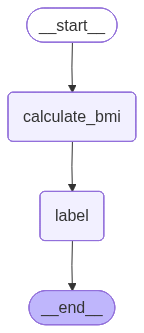

In [23]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())